# TP1 - Analyse de Données
## Guillaume Demerges - M1 DataEng

## Imports nécessaires

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_palette('husl')
%matplotlib inline

---
# Exercice 1 - Analyse des taxes d'habitation

### Question 1 : Importer le fichier capital.xls

In [52]:
df_capital = pd.read_excel('Capital.xls')

print("Dimensions du dataset:", df_capital.shape)
print("\nPremières lignes:")
print(df_capital.head())
print("\nInformations sur les colonnes:")
print(df_capital.info())
print("\nStatistiques descriptives:")
print(df_capital.describe())

Dimensions du dataset: (100, 3)

Premières lignes:
             Ville    TTH   Région
0  Aix en provence  18.94  Sud-Est
1          Ajaccio  22.06  Sud-Est
2           Amiens  17.97     Nord
3           Angers  18.86    Ouest
4           Annecy  14.97  Sud-Est

Informations sur les colonnes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Ville   100 non-null    object 
 1   TTH     100 non-null    float64
 2   Région  100 non-null    object 
dtypes: float64(1), object(2)
memory usage: 2.5+ KB
None

Statistiques descriptives:
              TTH
count  100.000000
mean    17.770700
std      5.529599
min      3.680000
25%     15.062500
50%     17.625000
75%     20.522500
max     36.170000


### Question 2 : Représenter graphiquement la répartition des régions (barplot et camembert)

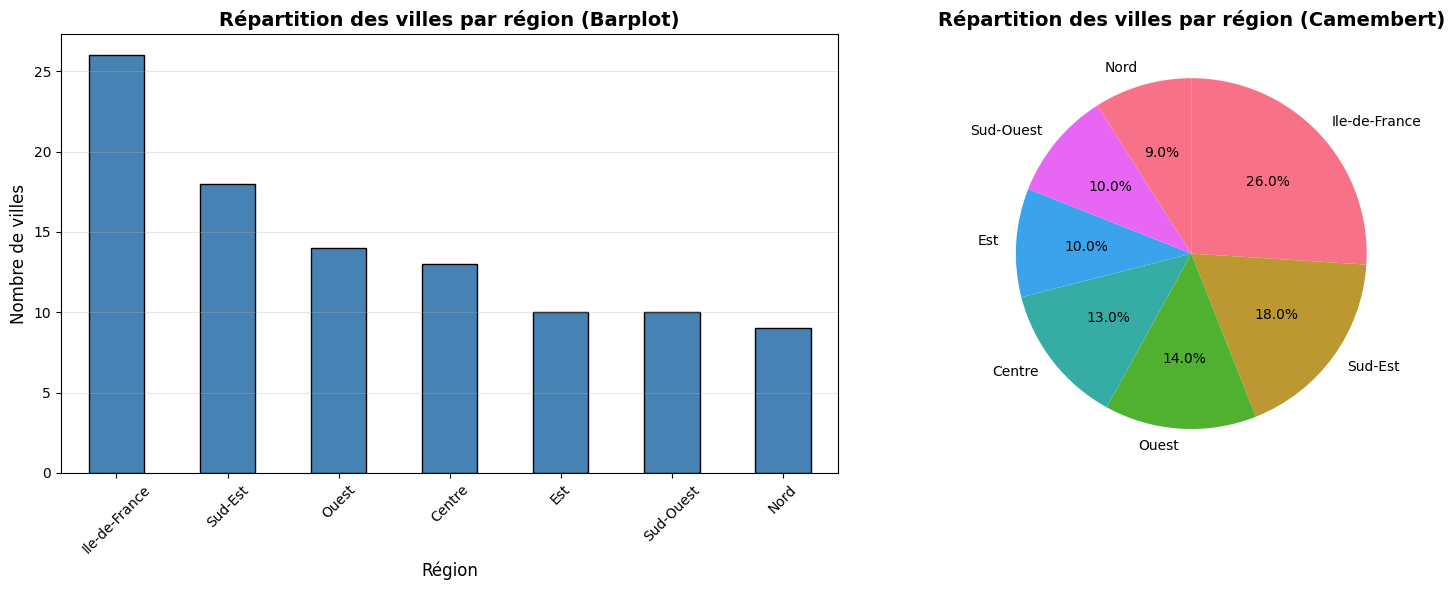

Nombre de villes par région:
Région
Ile-de-France    26
Sud-Est          18
Ouest            14
Centre           13
Est              10
Sud-Ouest        10
Nord              9
Name: count, dtype: int64


In [53]:
# Comptage des villes par région
region_counts = df_capital['Région'].value_counts()

# Création d'une figure avec 2 sous-graphiques
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot
region_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Répartition des villes par région (Barplot)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Région', fontsize=12)
axes[0].set_ylabel('Nombre de villes', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Camembert
axes[1].pie(region_counts.values, labels=region_counts.index, autopct='%1.1f%%', 
            startangle=90, counterclock=False)
axes[1].set_title('Répartition des villes par région (Camembert)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("Nombre de villes par région:")
print(region_counts)

### Question 3 : Quelle est la région la plus représentée ?

In [54]:
region_max = region_counts.idxmax()
nb_villes_max = region_counts.max()

print(f"La région la plus représentée est: {region_max}")
print(f"Nombre de villes: {nb_villes_max}")
print(f"Pourcentage: {(nb_villes_max / len(df_capital) * 100):.2f}%")

La région la plus représentée est: Ile-de-France
Nombre de villes: 26
Pourcentage: 26.00%


### Question 4 : Calculer les statistiques sur le taux de taxe d'habitation et les regrouper par région

=== Statistiques globales sur le taux de taxe d'habitation ===
count    100.000000
mean      17.770700
std        5.529599
min        3.680000
25%       15.062500
50%       17.625000
75%       20.522500
max       36.170000
Name: TTH, dtype: float64

Médiane: 17.62
Mode: 17.30

=== Statistiques par région ===
               Nombre  Moyenne  Médiane  Écart-type    Min    Max
Région                                                           
Ile-de-France      26    11.76    11.28        3.88   3.68  19.32
Est                10    17.66    16.98        2.10  14.98  22.04
Centre             13    18.12    17.37        1.91  15.77  21.55
Ouest              14    18.90    18.26        3.10  14.00  25.99
Sud-Est            18    19.77    19.58        2.94  14.30  25.98
Sud-Ouest          10    20.51    21.01        4.55  12.72  30.23
Nord                9    25.95    27.97        7.10  15.37  36.17


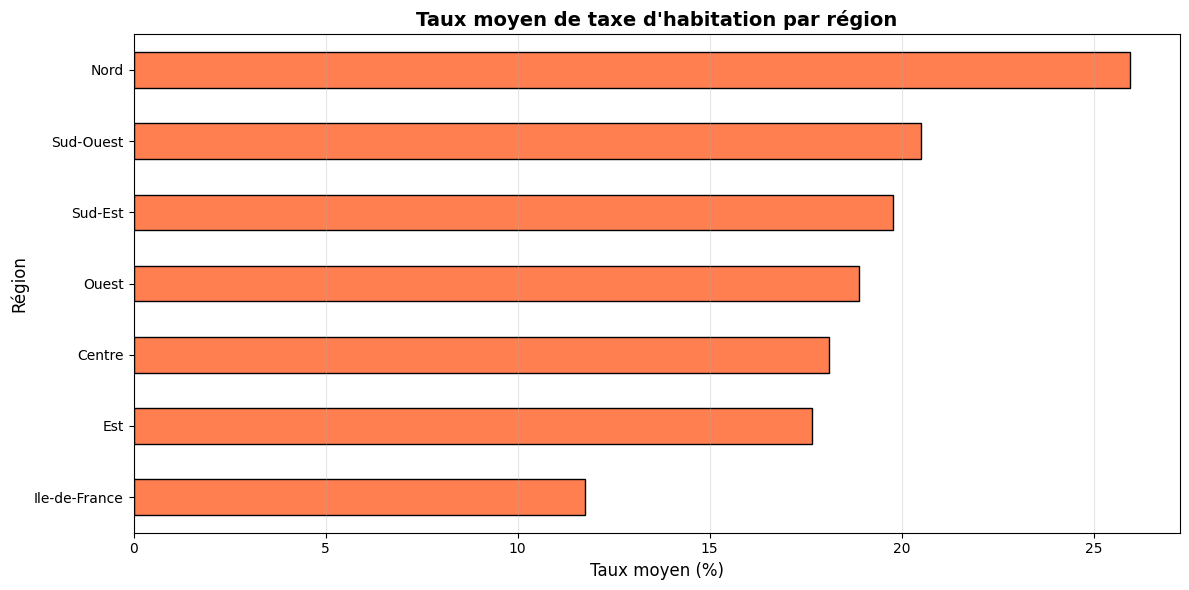

In [ ]:
print("=== Statistiques globales sur le taux de taxe d'habitation ===")
print(df_capital['TTH'].describe())
print(f"\nMédiane: {df_capital['TTH'].median():.2f}")
print(f"Mode: {df_capital['TTH'].mode().values[0]:.2f}")

print("\n=== Statistiques par région ===")
stats_par_region = df_capital.groupby('Région')['TTH'].agg([
    ('Nombre', 'count'),
    ('Moyenne', 'mean'),
    ('Médiane', 'median'),
    ('Écart-type', 'std'),
    ('Min', 'min'),
    ('Max', 'max')
]).round(2)

stats_par_region = stats_par_region.sort_values('Moyenne')
print(stats_par_region)

# Visualisation des moyennes par région
plt.figure(figsize=(12, 6))
stats_par_region['Moyenne'].plot(kind='barh', color='coral', edgecolor='black')
plt.title('Taux moyen de taxe d\'habitation par région', fontsize=14, fontweight='bold')
plt.xlabel('Taux moyen (%)', fontsize=12)
plt.ylabel('Région', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Question 5 : Quelle est la région la plus intéressante (taux moyen le plus faible) ?

In [ ]:
region_taux_min = stats_par_region['Moyenne'].idxmin()
taux_min = stats_par_region.loc[region_taux_min, 'Moyenne']

print(f"La région la plus intéressante (taux moyen le plus faible) est: {region_taux_min}")
print(f"Taux moyen: {taux_min:.2f}%")
print(f"\nDétails pour cette région:")
print(stats_par_region.loc[region_taux_min])

La région la plus intéressante (taux moyen le plus faible) est: Ile-de-France
Taux moyen: 11.76%

Détails pour cette région:
Nombre        26.00
Moyenne       11.76
Médiane       11.28
Écart-type     3.88
Min            3.68
Max           19.32
Name: Ile-de-France, dtype: float64


### Question 6 : Quelle est la région la plus représentative de la moyenne nationale ?

In [57]:
# Moyenne nationale
moyenne_nationale = df_capital['TTH'].mean()
print(f"Moyenne nationale: {moyenne_nationale:.2f}%")

# Calcul de l'écart entre chaque région et la moyenne nationale
stats_par_region['Écart_Moyenne_Nationale'] = abs(stats_par_region['Moyenne'] - moyenne_nationale)

# Région la plus proche de la moyenne nationale
region_representative = stats_par_region['Écart_Moyenne_Nationale'].idxmin()
ecart_min = stats_par_region.loc[region_representative, 'Écart_Moyenne_Nationale']

print(f"\nLa région la plus représentative de la moyenne nationale est: {region_representative}")
print(f"Taux moyen de la région: {stats_par_region.loc[region_representative, 'Moyenne']:.2f}%")
print(f"Écart avec la moyenne nationale: {ecart_min:.2f}%")

Moyenne nationale: 17.77%

La région la plus représentative de la moyenne nationale est: Est
Taux moyen de la région: 17.66%
Écart avec la moyenne nationale: 0.11%


### Question 7 : Typologie des villes en 3 groupes selon le taux de taxe d'habitation

=== Typologie des villes en 3 groupes ===

Bornes des groupes:
          min    max       mean  count
Groupe                                
Faible   3.68  16.20  12.268824     34
Moyen   16.25  19.43  17.893939     33
Élevé   19.48  36.17  23.316061     33


/var/folders/_g/p_6y26n95ms9zgxq6mzkh3gm0000gn/T/ipykernel_88185/3295248142.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_capital.groupby('Groupe')['TTH'].agg(['min', 'max', 'mean', 'count']))


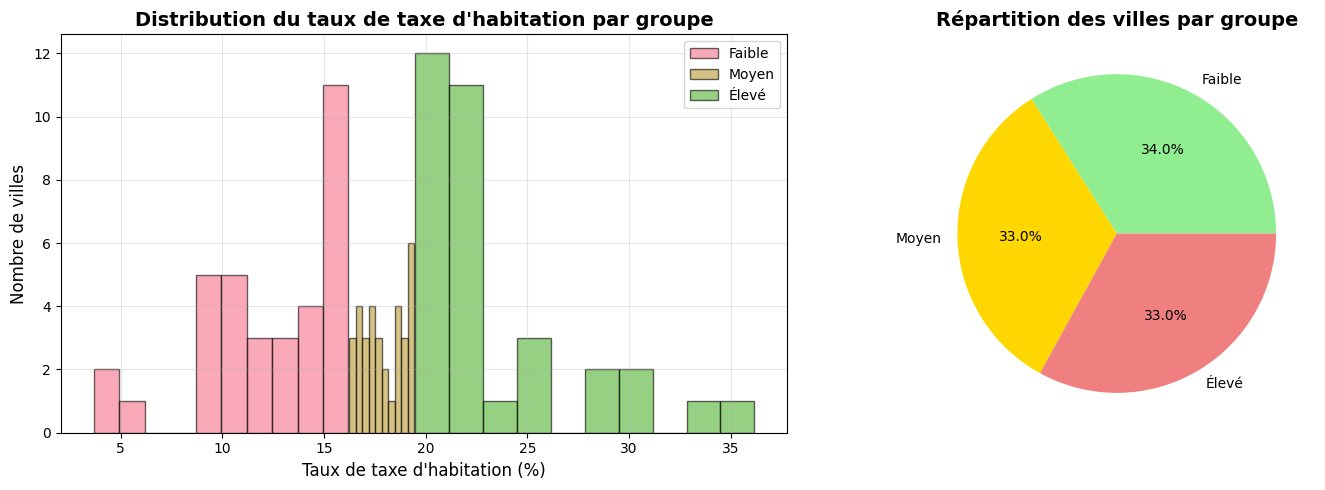


Exemples de villes par groupe:

Faible:
             Ville   TTH        Région
            Annecy 14.97       Sud-Est
           Antibes 14.30       Sud-Est
            Antony 11.07 Ile-de-France
Asnières-sur-Seine 10.13 Ile-de-France
     Aubervilliers 12.45 Ile-de-France

Moyen:
          Ville   TTH        Région
Aix en provence 18.94       Sud-Est
         Amiens 17.97          Nord
         Angers 18.86         Ouest
     Argenteuil 16.90 Ile-de-France
          Blois 17.07        Centre

Élevé:
   Ville   TTH    Région
 Ajaccio 22.06   Sud-Est
   Arles 24.49   Sud-Est
 Avignon 22.41   Sud-Est
Besançon 20.20       Est
 Béziers 22.14 Sud-Ouest


In [58]:
# Création de 3 groupes en utilisant les terciles
df_capital['Groupe'] = pd.qcut(df_capital['TTH'], 
                                q=3, 
                                labels=['Faible', 'Moyen', 'Élevé'])

# Affichage des bornes des groupes
print("=== Typologie des villes en 3 groupes ===")
print("\nBornes des groupes:")
print(df_capital.groupby('Groupe')['TTH'].agg(['min', 'max', 'mean', 'count']))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogramme avec les groupes
for groupe in ['Faible', 'Moyen', 'Élevé']:
    data = df_capital[df_capital['Groupe'] == groupe]['TTH']
    axes[0].hist(data, alpha=0.6, label=groupe, bins=10, edgecolor='black')

axes[0].set_title('Distribution du taux de taxe d\'habitation par groupe', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Taux de taxe d\'habitation (%)', fontsize=12)
axes[0].set_ylabel('Nombre de villes', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Répartition des groupes
groupe_counts = df_capital['Groupe'].value_counts()
axes[1].pie(groupe_counts.values, labels=groupe_counts.index, autopct='%1.1f%%', 
            colors=['lightgreen', 'gold', 'lightcoral'])
axes[1].set_title('Répartition des villes par groupe', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Quelques exemples de villes par groupe
print("\nExemples de villes par groupe:")
for groupe in ['Faible', 'Moyen', 'Élevé']:
    print(f"\n{groupe}:")
    villes = df_capital[df_capital['Groupe'] == groupe][['Ville', 'TTH', 'Région']].head(5)
    print(villes.to_string(index=False))

### Question 8 : Villes avec un taux ±30% de la moyenne

In [59]:
def villes_taux_extreme(df, colonne_taux, seuil_pct):
    moyenne = df[colonne_taux].mean()
    borne_sup = moyenne * (1 + seuil_pct / 100)
    borne_inf = moyenne * (1 - seuil_pct / 100)
    
    villes_au_dessus = df[df[colonne_taux] > borne_sup]
    villes_en_dessous = df[df[colonne_taux] < borne_inf]
    
    return villes_au_dessus, villes_en_dessous

villes_sup_30, villes_inf_30 = villes_taux_extreme(df_capital, 'TTH', 30)

moyenne = df_capital['TTH'].mean()
print(f"Moyenne nationale: {moyenne:.2f}%")
print(f"Borne supérieure (+30%): {moyenne * 1.3:.2f}%")
print(f"Borne inférieure (-30%): {moyenne * 0.7:.2f}%")

print(f"\n=== Villes avec un taux 30% au-dessus de la moyenne ({len(villes_sup_30)} villes) ===")
if len(villes_sup_30) > 0:
    print(villes_sup_30[['Ville', 'Région', 'TTH']].sort_values('TTH', ascending=False))
else:
    print("Aucune ville")

print(f"\n=== Villes avec un taux 30% en-dessous de la moyenne ({len(villes_inf_30)} villes) ===")
if len(villes_inf_30) > 0:
    print(villes_inf_30[['Ville', 'Région', 'TTH']].sort_values('TTH'))
else:
    print("Aucune ville")

Moyenne nationale: 17.77%
Borne supérieure (+30%): 23.10%
Borne inférieure (-30%): 12.44%

=== Villes avec un taux 30% au-dessus de la moyenne (10 villes) ===
               Ville     Région    TTH
49             Lille       Nord  36.17
91         Tourcoing       Nord  33.61
66             Nimes  Sud-Ouest  30.23
97  Villeneuve-d'Asq       Nord  29.96
39         Dunkerque       Nord  28.69
78           Roubaix       Nord  27.97
21             Brest      Ouest  25.99
45  La Seyne-sur-Mer    Sud-Est  25.98
8              Arles    Sud-Est  24.49
24            Calais       Nord  23.36

=== Villes avec un taux 30% en-dessous de la moyenne (16 villes) ===
                   Ville         Région    TTH
64     Neuilly-sur-Seine  Ile-de-France   3.68
35            Courbevoie  Ile-de-France   4.86
62              Nanterre  Ile-de-France   6.13
96            Versailles  Ile-de-France   8.95
70                 Paris  Ile-de-France   9.15
43        Ivry-sur-Seine  Ile-de-France   9.16
81           

### Question 9 : Villes avec un taux ±20% de la moyenne

In [60]:
villes_sup_20, villes_inf_20 = villes_taux_extreme(df_capital, 'TTH', 20)

print(f"Moyenne nationale: {moyenne:.2f}%")
print(f"Borne supérieure (+20%): {moyenne * 1.2:.2f}%")
print(f"Borne inférieure (-20%): {moyenne * 0.8:.2f}%")

print(f"\n=== Villes avec un taux 20% au-dessus de la moyenne ({len(villes_sup_20)} villes) ===")
if len(villes_sup_20) > 0:
    print(villes_sup_20[['Ville', 'Région', 'TTH']].sort_values('TTH', ascending=False))
else:
    print("Aucune ville")

print(f"\n=== Villes avec un taux 20% en-dessous de la moyenne ({len(villes_inf_20)} villes) ===")
if len(villes_inf_20) > 0:
    print(villes_inf_20[['Ville', 'Région', 'TTH']].sort_values('TTH'))
else:
    print("Aucune ville")

Moyenne nationale: 17.77%
Borne supérieure (+20%): 21.32%
Borne inférieure (-20%): 14.22%

=== Villes avec un taux 20% au-dessus de la moyenne (19 villes) ===
               Ville     Région    TTH
49             Lille       Nord  36.17
91         Tourcoing       Nord  33.61
66             Nimes  Sud-Ouest  30.23
97  Villeneuve-d'Asq       Nord  29.96
39         Dunkerque       Nord  28.69
78           Roubaix       Nord  27.97
21             Brest      Ouest  25.99
45  La Seyne-sur-Mer    Sud-Est  25.98
8              Arles    Sud-Est  24.49
24            Calais       Nord  23.36
12           Avignon    Sud-Est  22.41
16           Béziers  Sud-Ouest  22.14
18          Bordeaux  Sud-Ouest  22.11
1            Ajaccio    Sud-Est  22.06
88        Strasbourg        Est  22.04
54         Marseille    Sud-Est  21.93
77            Rennes      Ouest  21.75
74          Poitiers     Centre  21.55
58       Montpellier  Sud-Ouest  21.40

=== Villes avec un taux 20% en-dessous de la moyenne (21 vil

---
# Exercice 2 - Analyse des données de pauvreté

### Question 1 : Fonction pour tracer le nuage de points avec coefficient de corrélation

In [61]:
df_poverty = pd.read_csv('poverty.txt', sep='\s+', 
                         names=['Birth', 'Death', 'InfantDeath', 'Country', 'Continent'])

print("Dimensions du dataset:", df_poverty.shape)
print("\nPremières lignes:")
print(df_poverty.head(10))
print("\nInformations:")
print(df_poverty.info())
print("\nStatistiques:")
print(df_poverty.describe())

Dimensions du dataset: (97, 5)

Premières lignes:
   Birth  Death  InfantDeath            Country Continent
0   24.7    5.7         30.8            Albania    Europe
1   12.5   11.9         14.4           Bulgaria    Europe
2   13.4   11.7         11.3     Czechoslovakia    Europe
3   12.0   12.4          7.6  Former_E._Germany    Europe
4   11.6   13.4         14.8            Hungary    Europe
5   14.3   10.2         16.0             Poland    Europe
6   13.6   10.7         26.9            Romania    Europe
7   14.0    9.0         20.2         Yugoslavia    Europe
8   17.7   10.0         23.0               USSR    Europe
9   15.2    9.5         13.1   Byelorussian_SSR    Europe

Informations:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Birth        97 non-null     float64
 1   Death        97 non-null     float64
 2   InfantDeath  97 non-nu

In [62]:
def plot_scatter_with_correlation(df, x_col, y_col, title=None):
    # Calcul du coefficient de corrélation de Pearson
    correlation = df[x_col].corr(df[y_col])
    
    # Création du graphique
    plt.figure(figsize=(10, 6))
    plt.scatter(df[x_col], df[y_col], alpha=0.6, edgecolors='black', s=80)
    
    # Ajout d'une ligne de régression
    z = np.polyfit(df[x_col], df[y_col], 1)
    p = np.poly1d(z)
    plt.plot(df[x_col].sort_values(), p(df[x_col].sort_values()), 
             "r--", linewidth=2, label=f'Régression linéaire')
    
    if title is None:
        title = f'Nuage de points: {y_col} en fonction de {x_col}'
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(f'{x_col} (%)', fontsize=12)
    plt.ylabel(f'{y_col} (%)', fontsize=12)
    
    # Affichage du coefficient de corrélation
    plt.text(0.05, 0.95, f'Corrélation de Pearson: r = {correlation:.4f}', 
             transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Coefficient de corrélation entre {x_col} et {y_col}: r = {correlation:.4f}")
    
    # Interprétation
    if abs(correlation) > 0.7:
        force = "forte"
    elif abs(correlation) > 0.4:
        force = "modérée"
    else:
        force = "faible"
    
    sens = "positive" if correlation > 0 else "négative"
    print(f"Interprétation: Corrélation {force} {sens}\n")
    
    return correlation

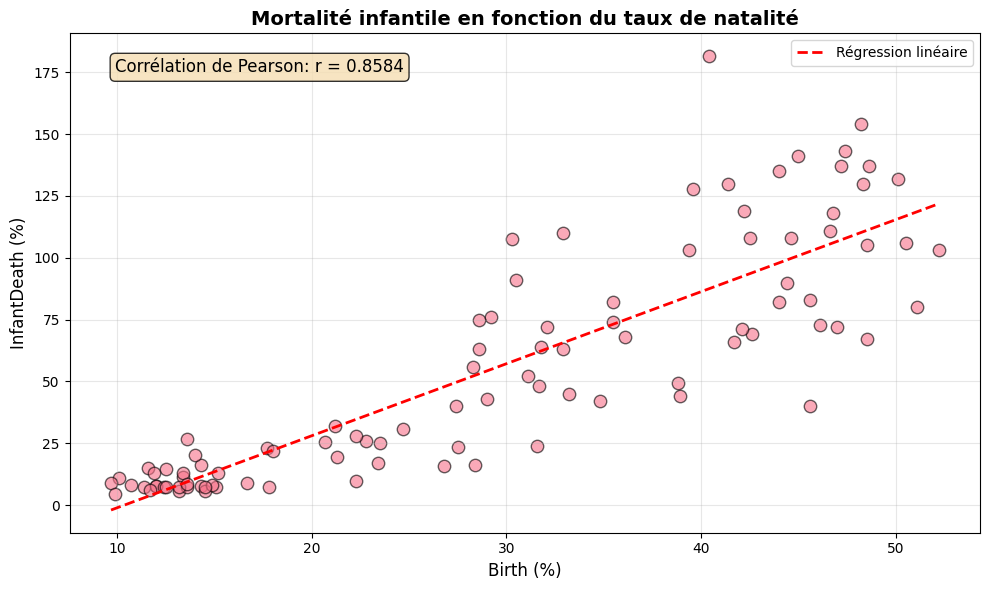

Coefficient de corrélation entre Birth et InfantDeath: r = 0.8584
Interprétation: Corrélation forte positive



In [63]:
corr1 = plot_scatter_with_correlation(df_poverty, 'Birth', 'InfantDeath',
                                       'Mortalité infantile en fonction du taux de natalité')

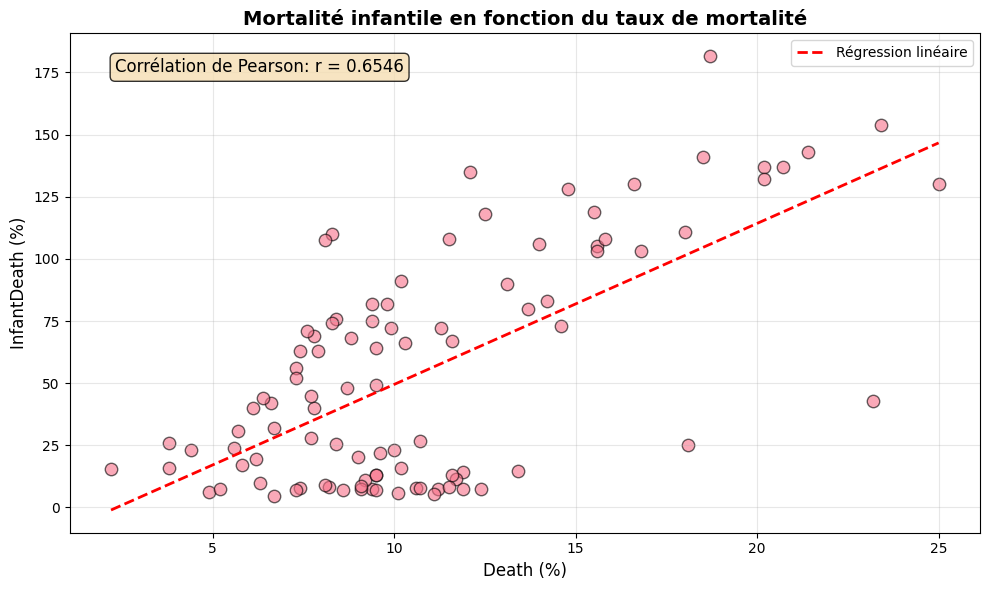

Coefficient de corrélation entre Death et InfantDeath: r = 0.6546
Interprétation: Corrélation modérée positive



In [64]:
corr2 = plot_scatter_with_correlation(df_poverty, 'Death', 'InfantDeath',
                                       'Mortalité infantile en fonction du taux de mortalité')

### Question 2 : Fonction pour représenter la distribution par continent avec boxplots

In [65]:
def plot_boxplot_by_continent(df, variable, title=None):
    # Création du graphique
    plt.figure(figsize=(12, 6))
    
    # Boxplot
    box_plot = df.boxplot(column=variable, by='Continent', 
                          figsize=(12, 6), patch_artist=True)
    
    # Personnalisation
    if title is None:
        title = f'Distribution de {variable} par continent'
    plt.suptitle('')  # Supprime le titre par défaut
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Continent', fontsize=12)
    plt.ylabel(f'{variable} (%)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Statistiques par continent
    print(f"\n=== Statistiques de {variable} par continent ===")
    stats = df.groupby('Continent')[variable].agg([
        ('Nombre', 'count'),
        ('Moyenne', 'mean'),
        ('Médiane', 'median'),
        ('Écart-type', 'std'),
        ('Min', 'min'),
        ('Max', 'max')
    ]).round(2)
    print(stats)
    
    # Comparaison des continents
    print(f"\n=== Analyse comparative ===")
    print(f"Continent avec la moyenne la plus élevée: {stats['Moyenne'].idxmax()} ({stats['Moyenne'].max():.2f}%)")
    print(f"Continent avec la moyenne la plus faible: {stats['Moyenne'].idxmin()} ({stats['Moyenne'].min():.2f}%)")
    print(f"Continent le plus variable (écart-type): {stats['Écart-type'].idxmax()} ({stats['Écart-type'].max():.2f})")
    
    return stats

<Figure size 1200x600 with 0 Axes>

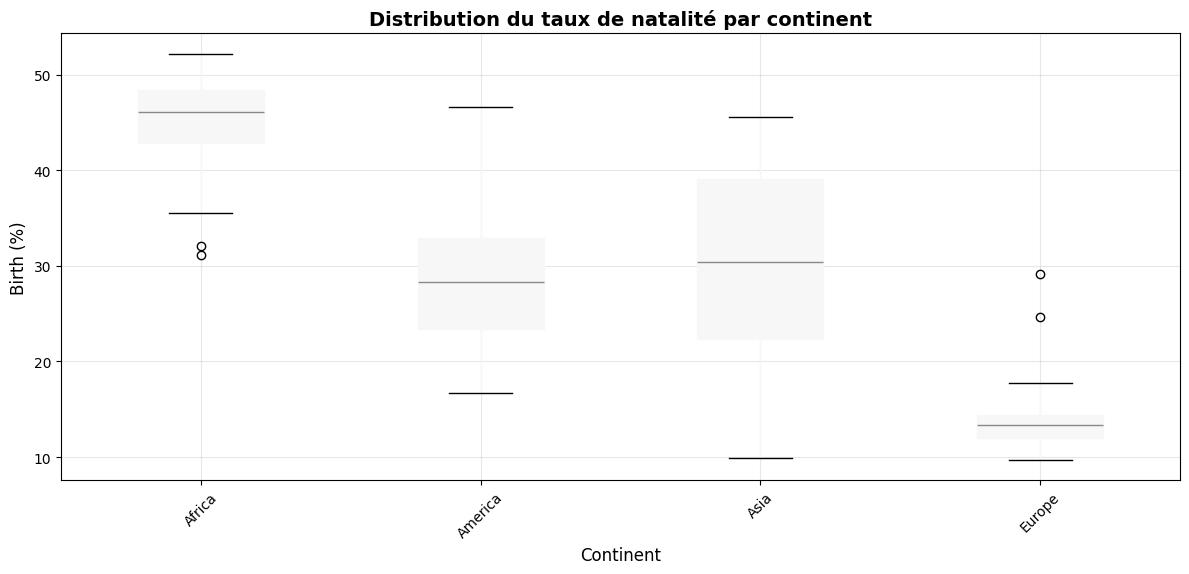


=== Statistiques de Birth par continent ===
           Nombre  Moyenne  Médiane  Écart-type   Min   Max
Continent                                                  
Africa         27    44.53     46.1        5.69  31.1  52.2
America        13    28.22     28.3        7.87  16.7  46.6
Asia           28    29.61     30.4        9.94   9.9  45.6
Europe         28    14.10     13.4        4.05   9.7  29.2

=== Analyse comparative ===
Continent avec la moyenne la plus élevée: Africa (44.53%)
Continent avec la moyenne la plus faible: Europe (14.10%)
Continent le plus variable (écart-type): Asia (9.94)


In [66]:
stats_birth = plot_boxplot_by_continent(df_poverty, 'Birth', 
                                        'Distribution du taux de natalité par continent')

<Figure size 1200x600 with 0 Axes>

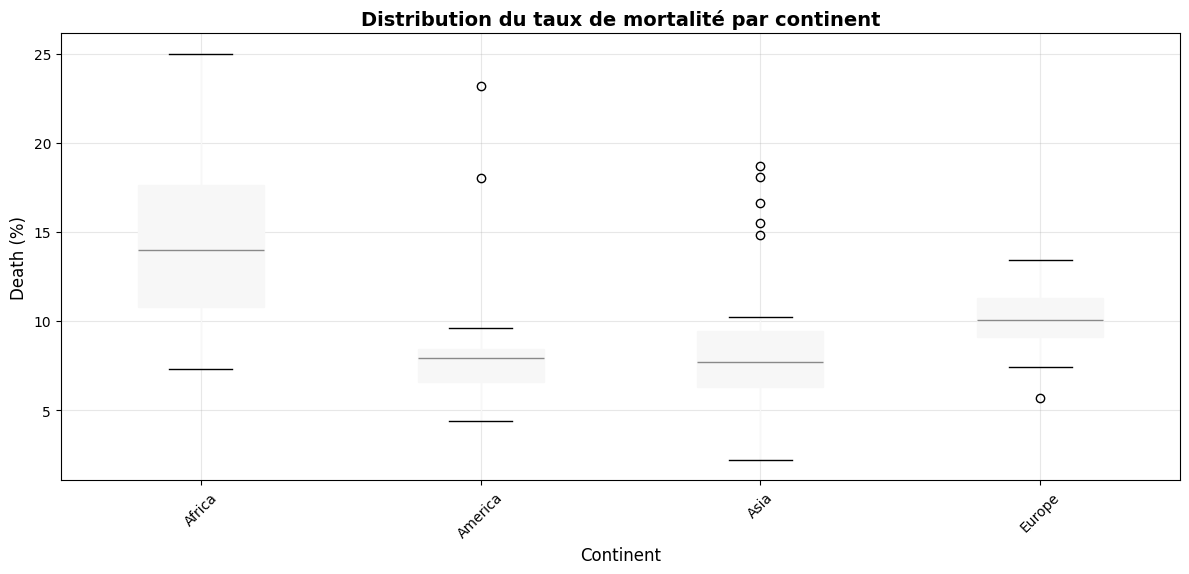


=== Statistiques de Death par continent ===
           Nombre  Moyenne  Médiane  Écart-type  Min   Max
Continent                                                 
Africa         27    14.62    14.00        4.80  7.3  25.0
America        13     9.32     7.90        5.29  4.4  23.2
Asia           28     8.65     7.70        4.29  2.2  18.7
Europe         28    10.06    10.05        1.65  5.7  13.4

=== Analyse comparative ===
Continent avec la moyenne la plus élevée: Africa (14.62%)
Continent avec la moyenne la plus faible: Asia (8.65%)
Continent le plus variable (écart-type): America (5.29)


In [67]:
stats_death = plot_boxplot_by_continent(df_poverty, 'Death',
                                        'Distribution du taux de mortalité par continent')

<Figure size 1200x600 with 0 Axes>

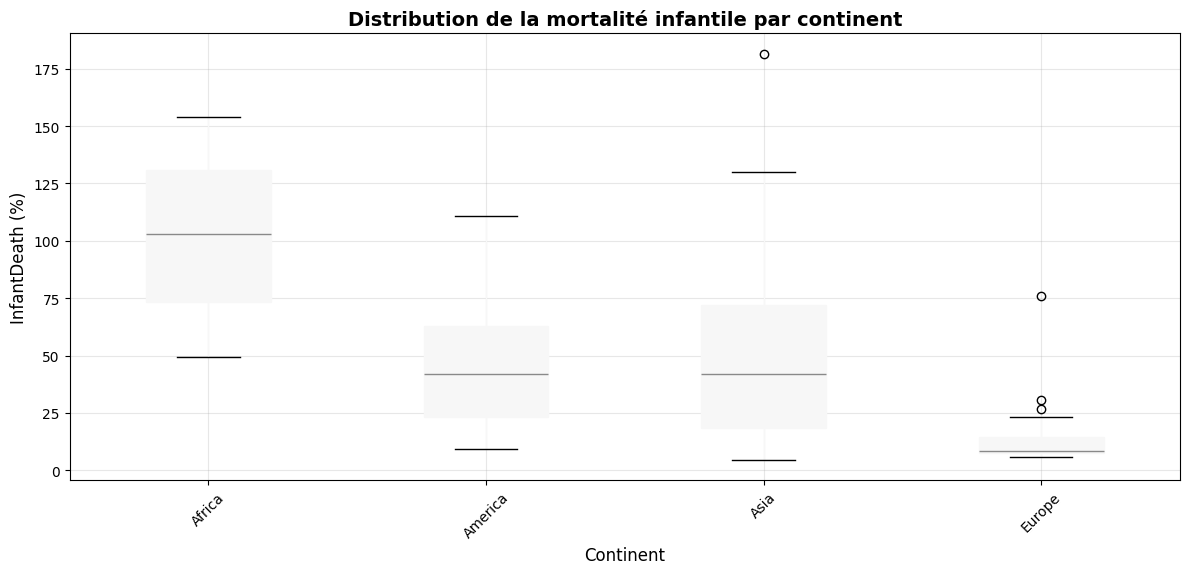


=== Statistiques de InfantDeath par continent ===
           Nombre  Moyenne  Médiane  Écart-type   Min    Max
Continent                                                   
Africa         27    99.79    103.0       30.58  49.4  154.0
America        13    48.08     42.0       32.53   9.1  111.0
Asia           28    53.65     42.0       45.76   4.5  181.6
Europe         28    14.13      8.6       13.72   5.6   76.0

=== Analyse comparative ===
Continent avec la moyenne la plus élevée: Africa (99.79%)
Continent avec la moyenne la plus faible: Europe (14.13%)
Continent le plus variable (écart-type): Asia (45.76)


In [68]:
stats_infant = plot_boxplot_by_continent(df_poverty, 'InfantDeath',
                                         'Distribution de la mortalité infantile par continent')

---
# Exercice 3 - Analyse des résultats en mathématiques des élèves

### Import et exploration des données

In [69]:
df_students = pd.read_csv('student-mat.csv', sep=';')

print("Dimensions du dataset:", df_students.shape)
print("\nPremières lignes:")
print(df_students.head())
print("\nInformations sur les colonnes:")
print(df_students.info())
print("\nStatistiques descriptives:")
print(df_students.describe())

print(f"Statistiques sur Results:")
print(df_students['Results'].describe())

Dimensions du dataset: (395, 22)

Premières lignes:
   Id  sex  age  address  famsize  Medu  Fedu  traveltime  studytime  \
0   1    0   18        1        1     4     4           2          2   
1   2    0   17        1        1     1     1           1          2   
2   3    0   15        1        0     1     1           1          2   
3   4    0   15        1        1     4     2           1          3   
4   5    0   16        1        1     3     3           1          2   

   failures  ...  internet  romantic  famrel  freetime  goout  Dalc  Walc  \
0         0  ...         0         0       4         3      4     1     1   
1         0  ...         1         0       5         3      3     1     1   
2         3  ...         1         0       4         3      2     2     3   
3         0  ...         1         1       3         2      2     1     1   
4         0  ...         0         0       4         3      2     1     2   

   health  absences  Results  
0       3         6  

### Question 1 : Fonction de calcul du coefficient de corrélation de Pearson

In [70]:
def pearson_correlation(x, y):
    # Conversion en numpy array
    x = np.array(x)
    y = np.array(y)
    
    # Calcul des moyennes
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    
    # Calcul de la covariance
    covariance = np.sum((x - mean_x) * (y - mean_y)) / len(x)
    
    # Calcul des écarts-types
    std_x = np.sqrt(np.sum((x - mean_x)**2) / len(x))
    std_y = np.sqrt(np.sum((y - mean_y)**2) / len(y))
    
    # Calcul du coefficient de corrélation
    correlation = covariance / (std_x * std_y)
    
    return correlation

test_corr = pearson_correlation(df_students['age'], df_students['Results'])
test_corr_pandas = df_students['age'].corr(df_students['Results'])
print(f"Corrélation calculée avec notre fonction: {test_corr:.6f}")
print(f"Corrélation calculée avec pandas: {test_corr_pandas:.6f}")
print(f"Différence: {abs(test_corr - test_corr_pandas):.10f}")
print("\nLa fonction fonctionne correctement!")

Corrélation calculée avec notre fonction: -0.161579
Corrélation calculée avec pandas: -0.161579
Différence: 0.0000000000

La fonction fonctionne correctement!


### Question 2 : Fonction d'analyse des corrélations avec la variable cible

In [ ]:
def analyze_correlations_with_target(df, target_col):
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col != target_col]
    
    # Calcul des corrélations avec notre fonction
    correlations = {}
    for col in numeric_cols:
        corr = pearson_correlation(df[col], df[target_col])
        correlations[col] = corr
    
    # Création d'un DataFrame pour faciliter le traitement
    df_corr = pd.DataFrame.from_dict(correlations, orient='index', columns=['Corrélation'])
    df_corr['Corrélation_abs'] = df_corr['Corrélation'].abs()
    df_corr = df_corr.sort_values('Corrélation_abs', ascending=False)
    
    # Identification des corrélations positives et négatives
    df_corr['Type'] = df_corr['Corrélation'].apply(lambda x: 'Positive' if x > 0 else 'Négative')
    
    # Affichage du tableau
    print(f"\n=== Corrélations avec {target_col} ===")
    print(df_corr[['Corrélation', 'Type']].to_string())
    
    # Statistiques
    print(f"\n=== Statistiques ===")
    print(f"Nombre de corrélations positives: {(df_corr['Corrélation'] > 0).sum()}")
    print(f"Nombre de corrélations négatives: {(df_corr['Corrélation'] < 0).sum()}")
    print(f"\nCorrélation la plus forte (positive): {df_corr[df_corr['Corrélation'] > 0]['Corrélation'].max():.4f}")
    print(f"Variable: {df_corr[df_corr['Corrélation'] > 0]['Corrélation'].idxmax()}")
    print(f"\nCorrélation la plus forte (négative): {df_corr[df_corr['Corrélation'] < 0]['Corrélation'].min():.4f}")
    if (df_corr['Corrélation'] < 0).any():
        print(f"Variable: {df_corr[df_corr['Corrélation'] < 0]['Corrélation'].idxmin()}")
    
    # Visualisation
    plt.figure(figsize=(12, 8))
    
    # Couleurs selon le signe
    colors = ['green' if x > 0 else 'red' for x in df_corr['Corrélation']]
    
    # Création du barplot
    bars = plt.barh(range(len(df_corr)), df_corr['Corrélation'], color=colors, edgecolor='black')
    plt.yticks(range(len(df_corr)), df_corr.index)
    plt.xlabel('Coefficient de corrélation', fontsize=12)
    plt.ylabel('Variables', fontsize=12)
    plt.title(f'Corrélations avec {target_col} (triées par valeur absolue)', 
              fontsize=14, fontweight='bold')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    plt.grid(axis='x', alpha=0.3)
    
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='green', edgecolor='black', label='Corrélation positive'),
                      Patch(facecolor='red', edgecolor='black', label='Corrélation négative')]
    plt.legend(handles=legend_elements, loc='best')
    
    plt.tight_layout()
    plt.show()
    
    return df_corr[['Corrélation', 'Type']]


=== Corrélations avec Results ===
            Corrélation      Type
failures      -0.360415  Négative
Medu           0.217147  Positive
age           -0.161579  Négative
Fedu           0.152457  Positive
goout         -0.132791  Négative
romantic      -0.129970  Négative
traveltime    -0.117142  Négative
address        0.105756  Positive
sex            0.103456  Positive
Id            -0.099991  Négative
internet       0.098483  Positive
studytime      0.097820  Positive
schoolsup     -0.082788  Négative
famsize       -0.081407  Négative
health        -0.061335  Négative
Dalc          -0.054660  Négative
Walc          -0.051939  Négative
famrel         0.051363  Positive
absences       0.034247  Positive
activities     0.016100  Positive
freetime       0.011307  Positive

=== Statistiques ===
Nombre de corrélations positives: 10
Nombre de corrélations négatives: 11

Corrélation la plus forte (positive): 0.2171
Variable: Medu

Corrélation la plus forte (négative): -0.3604
Variable: fai

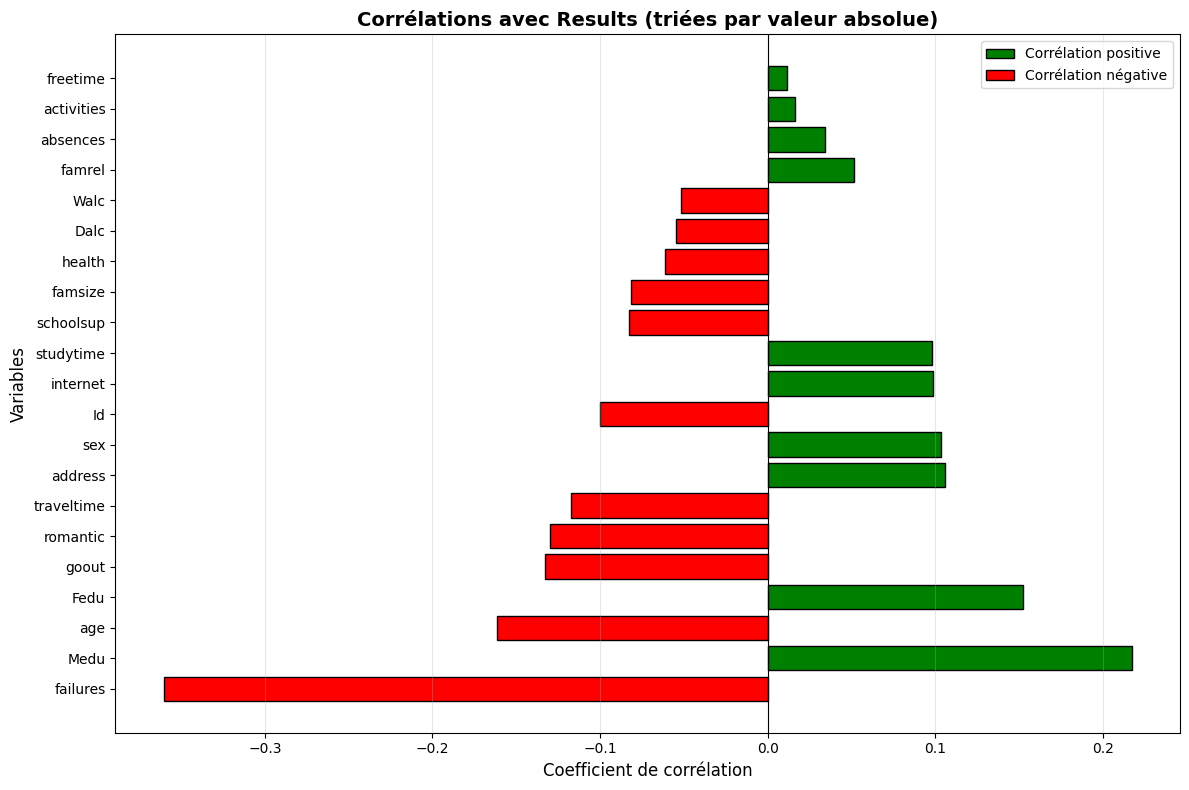

In [ ]:
correlations_results = analyze_correlations_with_target(df_students, 'Results')

### Question 3 : Les 3 variables les plus corrélées avec Results

In [ ]:
top_3 = correlations_results.nlargest(3, correlations_results.columns[0])

print("=== Les 3 variables les plus corrélées avec Results ===")
print(top_3)

print("\n=== Analyse détaillée ===")
for i, (var, row) in enumerate(top_3.iterrows(), 1):
    print(f"\n{i}. {var}")
    print(f"   Corrélation: {row['Corrélation']:.4f}")
    print(f"   Type: {row['Type']}")
    
    # Interprétation de la force
    abs_corr = abs(row['Corrélation'])
    if abs_corr > 0.7:
        force = "très forte"
    elif abs_corr > 0.5:
        force = "forte"
    elif abs_corr > 0.3:
        force = "modérée"
    else:
        force = "faible"
    print(f"   Interprétation: Corrélation {force}")

=== Les 3 variables les plus corrélées avec Results ===
         Corrélation      Type
Medu        0.217147  Positive
Fedu        0.152457  Positive
address     0.105756  Positive

=== Analyse détaillée ===

1. Medu
   Corrélation: 0.2171
   Type: Positive
   Interprétation: Corrélation faible

2. Fedu
   Corrélation: 0.1525
   Type: Positive
   Interprétation: Corrélation faible

3. address
   Corrélation: 0.1058
   Type: Positive
   Interprétation: Corrélation faible


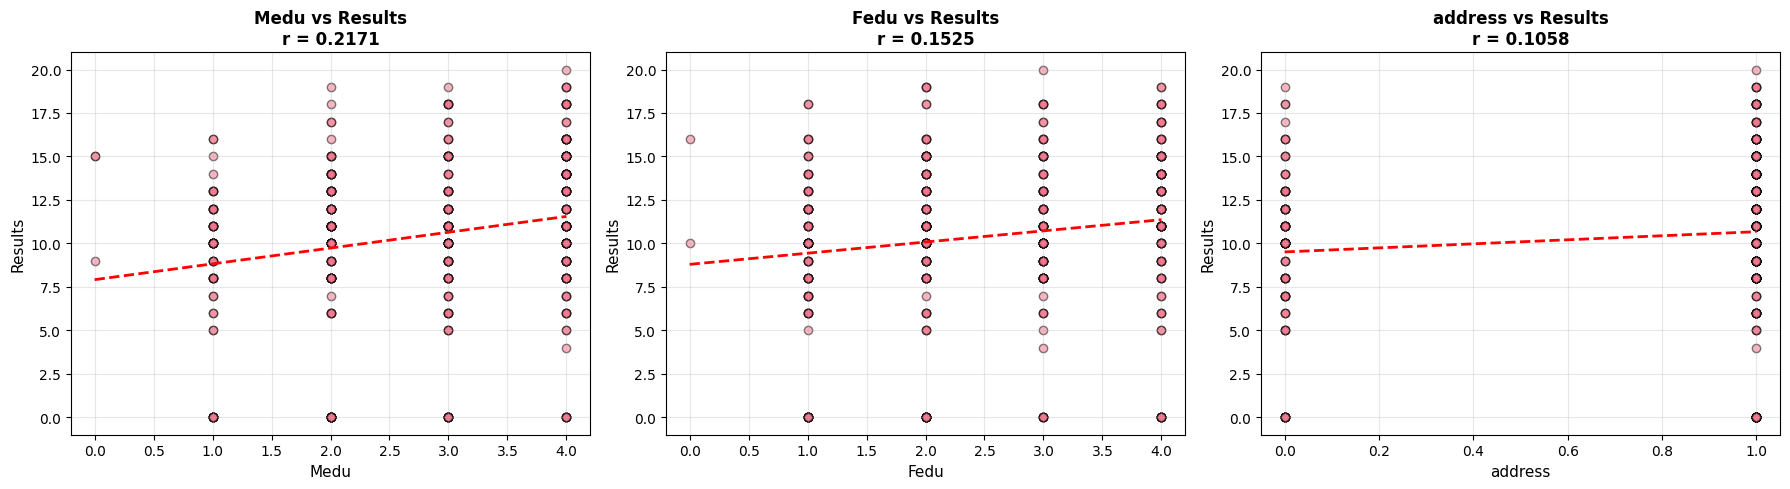

In [74]:
# Visualisation des relations entre Results et les 3 variables les plus corrélées
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (var, row) in enumerate(top_3.iterrows()):
    axes[idx].scatter(df_students[var], df_students['Results'], alpha=0.5, edgecolors='black')
    
    # Ligne de régression
    z = np.polyfit(df_students[var], df_students['Results'], 1)
    p = np.poly1d(z)
    axes[idx].plot(df_students[var].sort_values(), p(df_students[var].sort_values()), 
                   "r--", linewidth=2)
    
    axes[idx].set_xlabel(var, fontsize=11)
    axes[idx].set_ylabel('Results', fontsize=11)
    axes[idx].set_title(f'{var} vs Results\nr = {row["Corrélation"]:.4f}', 
                       fontsize=12, fontweight='bold')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()